<a href="https://colab.research.google.com/github/rahma1ayman/EMG_Signal_classification/blob/main/EMG_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os

# save_dir = "/content/drive/MyDrive/GRABMyo_subset/Session3/"
# os.makedirs(save_dir, exist_ok=True)

# base_url = "https://physionet.org/files/grabmyo/1.1.0/Session3/"

# participants = range(1,44)
# gestures = [15, 16]
# trials = range(1, 8)

# for pid in participants:
#     participant_folder = os.path.join(save_dir, f"session3_participant{pid}")
#     os.makedirs(participant_folder, exist_ok=True)

#     for gesture in gestures:
#         for trial in trials:
#             for ext in [".dat", ".hea"]:
#                 filename = f"session3_participant{pid}_gesture{gesture}_trial{trial}{ext}"
#                 url = base_url + f"session3_participant{pid}/" + filename
#                 save_path = os.path.join(participant_folder, filename)

#                 if os.path.exists(save_path):
#                     print(f"Already exists → {filename}")
#                     continue

#                 cmd = f'wget -O "{save_path}" "{url}"'
#                 status = os.system(cmd)

#                 if status == 0:
#                     print(f"Downloaded → {filename}")
#                 else:
#                     print(f"Failed → {filename}")

In [ ]:
# !pip install wfdb

In [ ]:
# import os
# import wfdb
# import numpy as np
# from scipy.io import savemat
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

# # فولدر الداتا الأساسي
# base_data_folder = "/content/drive/MyDrive/GRABMyo_subset"

# # Sessions
# # sessions = ["Session1", "Session2"]
# sessions = ["Session3"]

# # Participants و Gestures
# participants = range(1, 44)
# gestures = [15, 16]
# trials = range(1, 8)

# # Output folder
# output_folder = "/content/drive/MyDrive/Output_BM"

# # Channel mapping
# forearm_channels = np.concatenate((np.ones(8), np.ones(8), np.zeros(8), np.zeros(8))).astype(bool)
# wrist_channels = np.concatenate(
#     (np.zeros(8), np.zeros(8), np.zeros(1), np.ones(6), np.zeros(2), np.ones(6), np.zeros(1))
# ).astype(bool)

# # Loop على الـ sessions
# for session in sessions:

#     print(f"\n========== Processing {session} ==========")

#     data_folder = os.path.join(base_data_folder, session)

#     session_output_folder = os.path.join(output_folder, f"{session}_converted")
#     os.makedirs(session_output_folder, exist_ok=True)

#     # Loop على المشاركين
#     for pid in participants:

#         print(f"\nProcessing participant {pid} ...")

#         participant_folder = os.path.join(data_folder, f"{session.lower()}_participant{pid}")

#         matrices_forearm = np.empty((len(trials), len(gestures)), dtype=object)
#         matrices_wrist = np.empty((len(trials), len(gestures)), dtype=object)

#         for g_idx, gesture in enumerate(gestures):
#             for t_idx, trial in enumerate(trials):

#                 filename_base = f"{session.lower()}_participant{pid}_gesture{gesture}_trial{trial}"
#                 filepath = os.path.join(participant_folder, filename_base)

#                 hea_file = filepath + ".hea"
#                 dat_file = filepath + ".dat"

#                 if not (os.path.exists(hea_file) and os.path.exists(dat_file)):
#                     print(f"Missing file: {filename_base}")
#                     matrices_forearm[t_idx, g_idx] = None
#                     matrices_wrist[t_idx, g_idx] = None
#                     continue

#                 try:
#                     # قراءة الملف
#                     record = wfdb.rdrecord(filepath)
#                     data_emg = record.p_signal

#                     # تقسيم الإشارات
#                     data_forearm = data_emg[:, forearm_channels]
#                     data_wrist = data_emg[:, wrist_channels]

#                     matrices_forearm[t_idx, g_idx] = data_forearm
#                     matrices_wrist[t_idx, g_idx] = data_wrist

#                     print(f"Read: {filename_base} -> {data_emg.shape}")

#                 except Exception as e:
#                     print(f"Error reading {filename_base}: {e}")
#                     matrices_forearm[t_idx, g_idx] = None
#                     matrices_wrist[t_idx, g_idx] = None

#         # حفظ ملف .mat
#         save_path = os.path.join(session_output_folder, f"{session.lower()}_participant{pid}.mat")

#         savemat(save_path, {
#             "DATA_FOREARM": matrices_forearm,
#             "DATA_WRIST": matrices_wrist
#         })

#         print(f"Saved -> {save_path}")

# print("\nAll sessions processed!")

In [ ]:
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch
import numpy as np
import math
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier , VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


Num Trials: 7 Num Gestures: 2
Timesteps: 10240 Num Channels: 16


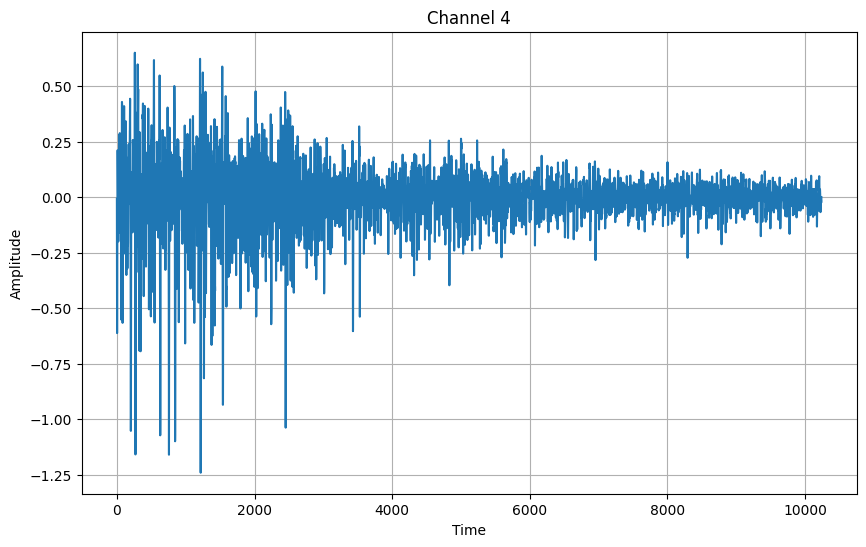

In [ ]:

# Load the .mat file
mat_data = loadmat('/content/drive/MyDrive/Output_BM/Session1_converted/session1_participant1.mat')

# Access the data
data = mat_data["DATA_FOREARM"]
print("Num Trials:", data.shape[0], "Num Gestures:", data.shape[1])

# Choose data from one run
data_to_plot = data[1,1]
print("Timesteps:", data_to_plot.shape[0], "Num Channels:", data_to_plot.shape[1])

# randomly choose one channel
ichannel = np.random.randint(0, data_to_plot.shape[1])
time = range(data_to_plot.shape[0])
plt.figure(figsize=(10, 6))
plt.plot(time, data_to_plot[:, ichannel])
plt.title('Channel {}'.format(ichannel + 1))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Num Trials: 7 Num Gestures: 2


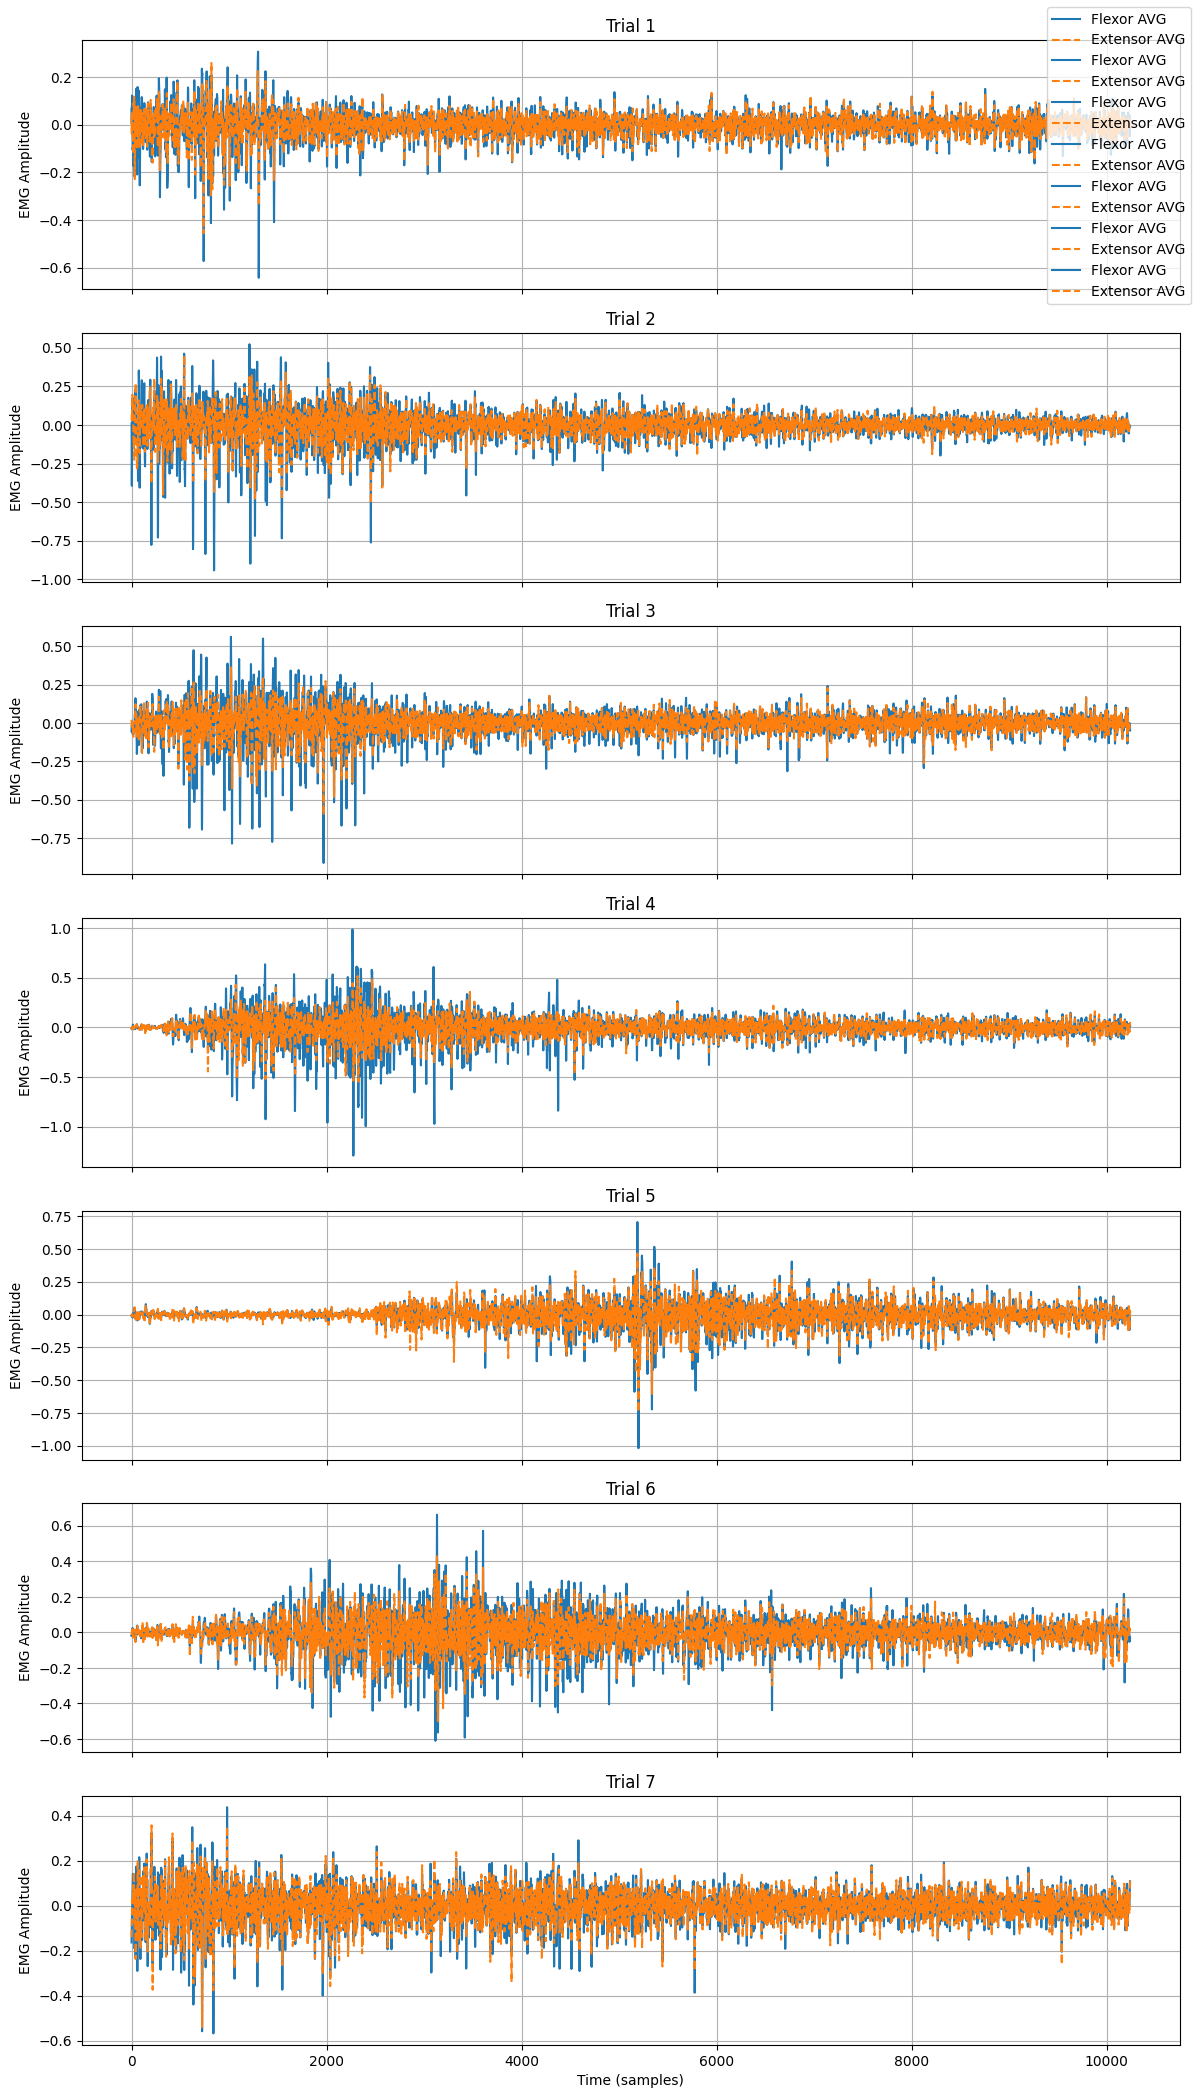

In [ ]:

# Load the .mat file
mat_data = loadmat('/content/drive/MyDrive/Output_BM/Session1_converted/session1_participant1.mat')

# Access forearm data
data = mat_data["DATA_FOREARM"]
print("Num Trials:", data.shape[0], "Num Gestures:", data.shape[1])

# Flexor and Extensor channel indices (0-based)
flexor_idx = [0, 1, 2, 3]    # channels 1-4
extensor_idx = [4, 5, 6, 7]  # channels 5-8

# Choose gesture to plot (0-based)
gesture_idx = 1  # gesture 16

num_trials = data.shape[0]

# Create subplots: one row per trial
fig, axes = plt.subplots(num_trials, 1, figsize=(12, 3*num_trials), sharex=True)

if num_trials == 1:
    axes = [axes]

for trial_idx in range(num_trials):
    data_to_plot = data[trial_idx, gesture_idx]
    timesteps = data_to_plot.shape[0]

    # ⭐ Average signals
    flexor_avg = np.mean(data_to_plot[:, flexor_idx], axis=1)
    extensor_avg = np.mean(data_to_plot[:, extensor_idx], axis=1)

    ax = axes[trial_idx]

    ax.plot(range(timesteps), flexor_avg, label='Flexor AVG', linewidth=1.5)
    ax.plot(range(timesteps), extensor_avg, label='Extensor AVG', linewidth=1.5, linestyle='--')

    ax.set_title(f'Trial {trial_idx+1}')
    ax.set_ylabel('EMG Amplitude')
    ax.grid(True)

axes[-1].set_xlabel('Time (samples)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Siganl Preprocessing

In [ ]:

# signal processing functions
def bandpass_filter(signal, fs=2000, lowcut=20, highcut=450, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)

def notch_filter(signal, fs=2000, f0=50.0, Q=30.0):
    b, a = iirnotch(f0, Q, fs)
    return filtfilt(b, a, signal, axis=0)

def smooth_signal(signal, window_size=200):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

# processing
def preprocess_emg(signal, fs=2048, smooth_win=200):
    filt = bandpass_filter(signal, fs)
    filt = notch_filter(filt, fs)
    rect = np.abs(filt)
    env = np.array([smooth_signal(ch, smooth_win) for ch in rect.T]).T
    return env, filt


In [ ]:
# Segment Signals and return raw signal and signal after processing
def segment_signal(raw_signal, env_signal, window_size, step):

    raw_segments = []
    env_segments = []

    for start in range(0, raw_signal.shape[0] - window_size + 1, step):

        end = start + window_size

        raw_segments.append(raw_signal[start:end, :])
        env_segments.append(env_signal[start:end, :])

    return raw_segments, env_segments

### Feature Extraction

In [ ]:

def extract_features(segment_raw, segment_env):

    features = []

    for ch in range(segment_raw.shape[1]):

        x_raw = segment_raw[:, ch]
        x_env = segment_env[:, ch]

        mav = np.mean(np.abs(x_env))
        rms = np.sqrt(np.mean(x_env**2))
        var = np.var(x_env)
        wl = np.sum(np.abs(np.diff(x_env)))

        # ZC
        zc = np.sum(x_raw[:-1] * x_raw[1:] < 0)

        # SSC
        diff = np.diff(x_raw)
        ssc = np.sum(diff[:-1] * diff[1:] < 0)

        # WAMP
        wamp = np.sum(np.abs(np.diff(x_raw)) > 0.01)

        features.extend([mav, rms, var, wl, zc, ssc, wamp])

    return np.array(features)

In [ ]:
# Dataset Parameters

sessions = ["Session1", "Session2","Session3"]
data_folder = "/content/drive/MyDrive/Output_BM"
participants = range(1, 16)
gestures = [15, 16]   # Open, Close
fs = 2048
smooth_win = 50
window_size = int(0.2 * fs)   # 200 ms
step = int(window_size * 0.5) # 50% overlap

# Forearm channel indices (0-based)
flexor_idx = [0, 1, 2, 3]
extensor_idx = [4, 5, 6, 7]


X_features = []
Y_labels = []
session_labels = []

In [ ]:
for session in sessions:
    session_folder = os.path.join(data_folder, f"{session}_converted")

    for pid in participants:
        file_path = os.path.join(session_folder, f"{session.lower()}_participant{pid}.mat")

        if not os.path.exists(file_path):
            print("Missing:", file_path)
            continue

        mat_data = loadmat(file_path)
        data_forearm = mat_data["DATA_FOREARM"]

        num_trials, num_gestures = data_forearm.shape

        for g_idx, gesture in enumerate(gestures):
            label = 0 if gesture == 15 else 1

            for trial_idx in range(num_trials):
                trial_data = data_forearm[trial_idx, g_idx]

                if trial_data is None:
                    continue
                if not hasattr(trial_data, "shape"):
                    continue
                if len(trial_data.shape) != 2:
                    continue

                # channels
                flexor_data = trial_data[:, flexor_idx]
                extensor_data = trial_data[:, extensor_idx]

                # preprocess
                flexor_raw, flexor_env = preprocess_emg(flexor_data, fs, smooth_win)
                extensor_raw, extensor_env = preprocess_emg(extensor_data, fs, smooth_win)

                # average 4 channels of each muscle -> 1 channel per muscle
                flexor_raw_avg = np.mean(flexor_raw, axis=1, keepdims=True)
                extensor_raw_avg = np.mean(extensor_raw, axis=1, keepdims=True)

                flexor_env_avg = np.mean(flexor_env, axis=1, keepdims=True)
                extensor_env_avg = np.mean(extensor_env, axis=1, keepdims=True)

                # final signal = 2 channels
                full_raw_signal = np.concatenate(
                    [flexor_raw_avg, extensor_raw_avg], axis=1
                )

                full_env_signal = np.concatenate(
                    [flexor_env_avg, extensor_env_avg], axis=1
                )

                # segmentation
                raw_segments, env_segments = segment_signal(
                    full_raw_signal,
                    full_env_signal,
                    window_size,
                    step
                )

                for seg_raw, seg_env in zip(raw_segments, env_segments):
                    feat = extract_features(seg_raw, seg_env)
                    X_features.append(feat)
                    Y_labels.append(label)
                    session_labels.append(session)

X_features = np.array(X_features)
Y_labels = np.array(Y_labels)
session_labels = np.array(session_labels)

print("X_features shape:", X_features.shape)
print("Y_labels shape:", Y_labels.shape)
print("session_labels shape:", session_labels.shape)

X_features shape: (30870, 14)
Y_labels shape: (30870,)
session_labels shape: (30870,)


In [ ]:
print(np.unique(Y_labels, return_counts=True))

(array([0, 1]), array([15435, 15435]))


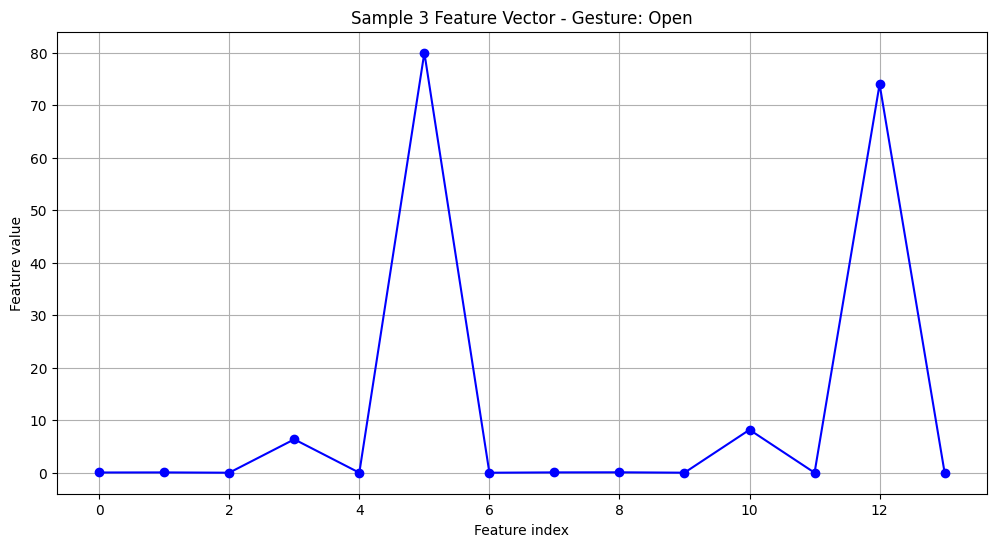

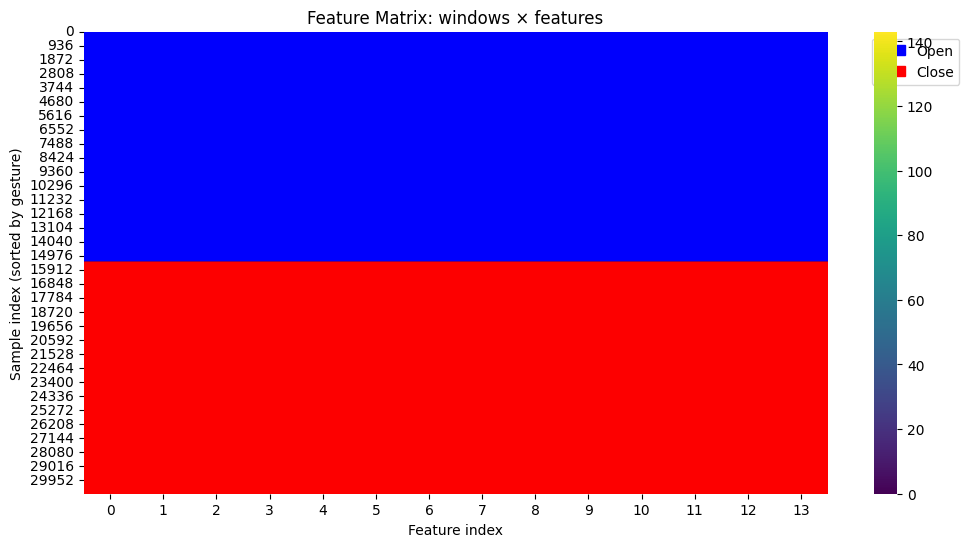

In [ ]:
gesture_names = {0: 'Open', 1: 'Close'}
gesture_colors = {0: 'blue', 1: 'red'}

sample_idx = 2

gesture = Y_labels[sample_idx]
color = gesture_colors[gesture]

# -------------------------
# 1) Feature vector plot
# -------------------------
sample_feat = X_features[sample_idx]

plt.figure(figsize=(12, 6))
plt.plot(sample_feat, marker='o', color=color)
plt.title(f'Sample {sample_idx+1} Feature Vector - Gesture: {gesture_names[gesture]}')
plt.xlabel('Feature index')
plt.ylabel('Feature value')
plt.grid(True)
plt.show()

# -------------------------
# 2) Heatmap
# -------------------------
sort_idx = np.argsort(Y_labels)
X_sorted = X_features[sort_idx]
Y_sorted = Y_labels[sort_idx]

plt.figure(figsize=(12, 6))
sns.heatmap(X_sorted, cmap='viridis', cbar=True)
plt.title('Feature Matrix: windows × features')
plt.xlabel('Feature index')
plt.ylabel('Sample index (sorted by gesture)')

for i in range(len(Y_sorted)):
    plt.axhline(i, color=gesture_colors[Y_sorted[i]], linewidth=1.5, alpha=0.35)

blue_patch = mpatches.Patch(color='blue', label='Open')
red_patch = mpatches.Patch(color='red', label='Close')
plt.legend(handles=[blue_patch, red_patch], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

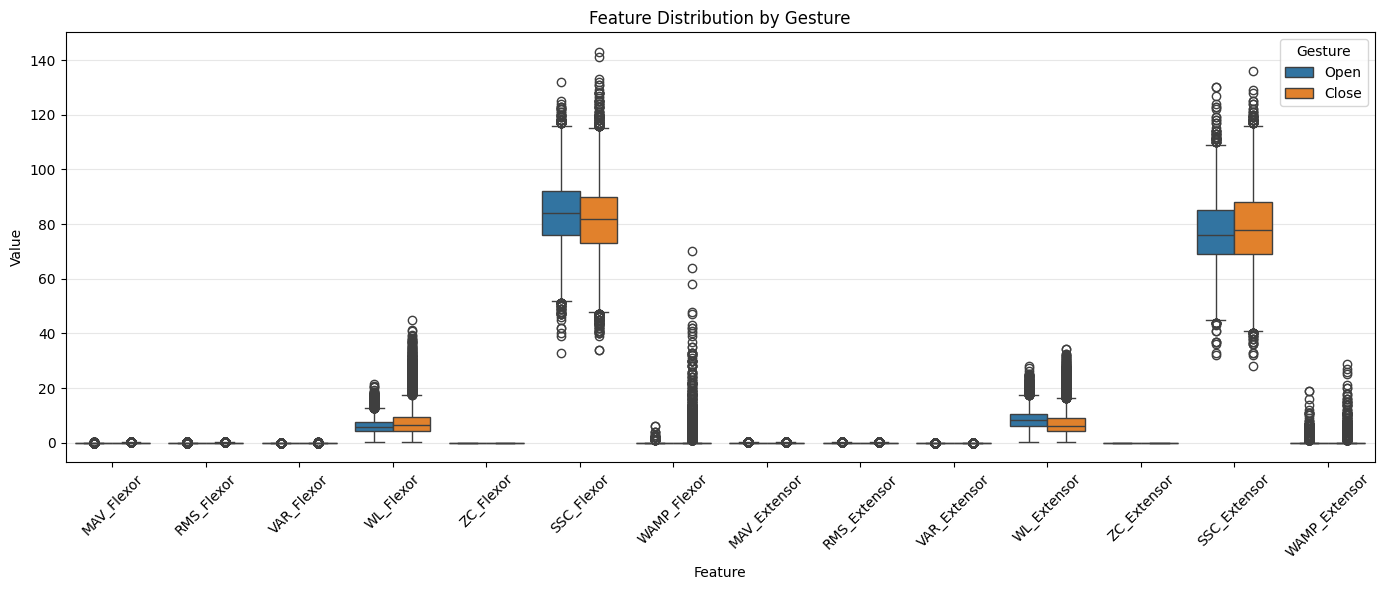

In [ ]:
feature_names = [
    'MAV_Flexor', 'RMS_Flexor', 'VAR_Flexor', 'WL_Flexor','ZC_Flexor','SSC_Flexor','WAMP_Flexor',
    'MAV_Extensor', 'RMS_Extensor', 'VAR_Extensor', 'WL_Extensor','ZC_Extensor','SSC_Extensor','WAMP_Extensor'
]

df_features = pd.DataFrame(X_features, columns=feature_names)
df_features["Gesture"] = [gesture_names[y] for y in Y_labels]

df_long = df_features.melt(id_vars="Gesture", var_name="Feature", value_name="Value")

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_long, x="Feature", y="Value", hue="Gesture")
plt.title("Feature Distribution by Gesture")
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

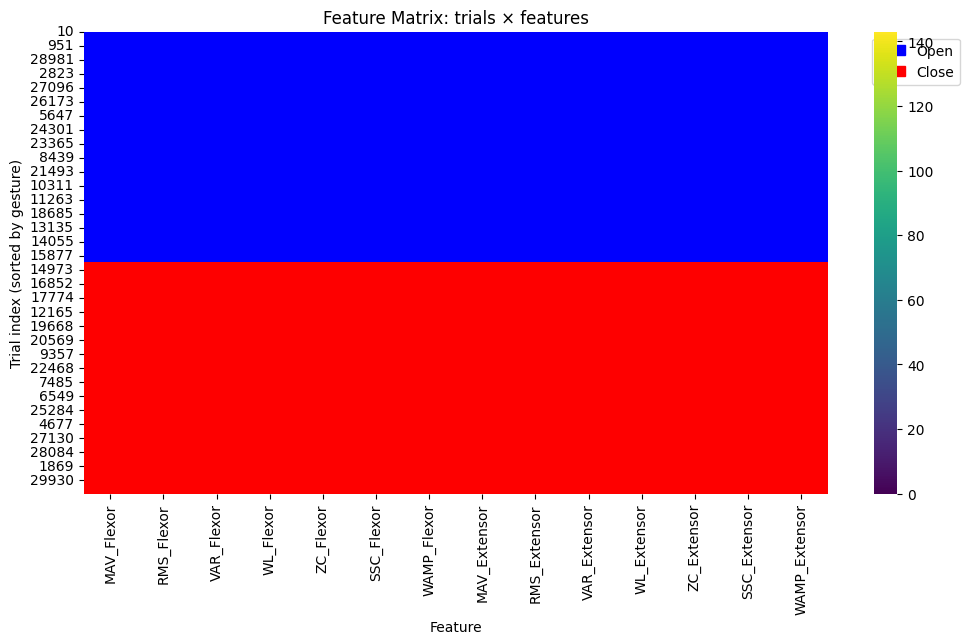

In [ ]:


X_df = pd.DataFrame(X_features, columns=feature_names)
Y_series = pd.Series(Y_labels, name='Gesture')

sorted_idx = Y_series.sort_values().index
X_df_sorted = X_df.loc[sorted_idx]
Y_sorted = Y_series.loc[sorted_idx]

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(X_df_sorted, cmap='viridis', cbar=True)
plt.title('Feature Matrix: trials × features')
plt.xlabel('Feature')
plt.ylabel('Trial index (sorted by gesture)')

gesture_colors = {0: 'blue', 1: 'red'}
for i, g in enumerate(Y_sorted):
    plt.axhline(i, color=gesture_colors[g], linewidth=2, alpha=0.5)

blue_patch = mpatches.Patch(color='blue', label='Open')
red_patch = mpatches.Patch(color='red', label='Close')
plt.legend(handles=[blue_patch, red_patch], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


# Modeling

### Split Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_features, Y_labels, test_size=0.2, random_state=42,stratify=Y_labels
)

In [ ]:
np.unique(Y_train, return_counts=True)

(array([0, 1]), array([12348, 12348]))

In [ ]:
# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
results = {}

### Logestic Regression

In [ ]:
logreg_model = LogisticRegression(max_iter=1000, random_state=42)

logreg_cv_scores = cross_val_score(logreg_model, X_train_scaled, Y_train, cv=5, scoring='accuracy')
logreg_model.fit(X_train_scaled, Y_train)
y_pred_logreg = logreg_model.predict(X_test_scaled)
logreg_test_accuracy = accuracy_score(Y_test, y_pred_logreg)

results['Logistic Regression'] = {
    'cv_mean': logreg_cv_scores.mean(),
    'cv_std': logreg_cv_scores.std(),
    'test_accuracy': logreg_test_accuracy,
    'predictions': y_pred_logreg,
    'model': logreg_model
}

print(f"   CV Accuracy: {logreg_cv_scores.mean():.3f} (+/- {logreg_cv_scores.std()*2:.3f})")
print(f"   Test Accuracy: {logreg_test_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_logreg))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_logreg))

   CV Accuracy: 0.901 (+/- 0.008)
   Test Accuracy: 0.906

Confusion Matrix:
[[2764  323]
 [ 260 2827]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      3087
           1       0.90      0.92      0.91      3087

    accuracy                           0.91      6174
   macro avg       0.91      0.91      0.91      6174
weighted avg       0.91      0.91      0.91      6174



### Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_cv_scores = cross_val_score(dt_model, X_train, Y_train, cv=5, scoring='accuracy')
dt_model.fit(X_train, Y_train)
y_pred_dt = dt_model.predict(X_test)
dt_test_accuracy = accuracy_score(Y_test, y_pred_dt)

results['Decision Tree'] = {
    'cv_mean': dt_cv_scores.mean(),
    'cv_std': dt_cv_scores.std(),
    'test_accuracy': dt_test_accuracy,
    'predictions': y_pred_dt,
    'model': dt_model
}

print(f"   CV Accuracy: {dt_cv_scores.mean():.3f} (+/- {dt_cv_scores.std()*2:.3f})")
print(f"   Test Accuracy: {dt_test_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_dt))

   CV Accuracy: 0.892 (+/- 0.010)
   Test Accuracy: 0.894

Confusion Matrix:
[[2789  298]
 [ 355 2732]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3087
           1       0.90      0.89      0.89      3087

    accuracy                           0.89      6174
   macro avg       0.89      0.89      0.89      6174
weighted avg       0.89      0.89      0.89      6174



### Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

rf_cv_scores = cross_val_score(rf_model, X_train, Y_train, cv=5, scoring='accuracy')
rf_model.fit(X_train, Y_train)
y_pred_rf = rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(Y_test, y_pred_rf)

results['Random Forest'] = {
    'cv_mean': rf_cv_scores.mean(),
    'cv_std': rf_cv_scores.std(),
    'test_accuracy': rf_test_accuracy,
    'predictions': y_pred_rf,
    'model': rf_model
}

print(f"   CV Accuracy: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std()*2:.3f})")
print(f"   Test Accuracy: {rf_test_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

   CV Accuracy: 0.906 (+/- 0.007)
   Test Accuracy: 0.906

Confusion Matrix:
[[2805  282]
 [ 296 2791]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      3087
           1       0.91      0.90      0.91      3087

    accuracy                           0.91      6174
   macro avg       0.91      0.91      0.91      6174
weighted avg       0.91      0.91      0.91      6174



### SVM

In [ ]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True)

svm_cv_scores = cross_val_score(svm_model, X_train_scaled, Y_train, cv=5, scoring='accuracy')
svm_model.fit(X_train_scaled, Y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
svm_test_accuracy = accuracy_score(Y_test, y_pred_svm)

results['SVM (RBF)'] = {
    'cv_mean': svm_cv_scores.mean(),
    'cv_std': svm_cv_scores.std(),
    'test_accuracy': svm_test_accuracy,
    'predictions': y_pred_svm,
    'model': svm_model
}

print(f"   CV Accuracy: {svm_cv_scores.mean():.3f} (+/- {svm_cv_scores.std()*2:.3f})")
print(f"   Test Accuracy: {svm_test_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_svm))

   CV Accuracy: 0.916 (+/- 0.008)
   Test Accuracy: 0.917

Confusion Matrix:
[[2826  261]
 [ 250 2837]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3087
           1       0.92      0.92      0.92      3087

    accuracy                           0.92      6174
   macro avg       0.92      0.92      0.92      6174
weighted avg       0.92      0.92      0.92      6174



### KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_cv_scores = cross_val_score(knn_model, X_train_scaled, Y_train, cv=5, scoring='accuracy')
knn_model.fit(X_train_scaled, Y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_test_accuracy = accuracy_score(Y_test, y_pred_knn)

results['KNN (k=3)'] = {
    'cv_mean': knn_cv_scores.mean(),
    'cv_std': knn_cv_scores.std(),
    'test_accuracy': knn_test_accuracy,
    'predictions': y_pred_knn,
    'model': knn_model
}

print(f"   CV Accuracy: {knn_cv_scores.mean():.3f} (+/- {knn_cv_scores.std()*2:.3f})")
print(f"   Test Accuracy: {knn_test_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_knn))


   CV Accuracy: 0.881 (+/- 0.009)
   Test Accuracy: 0.881

Confusion Matrix:
[[2726  361]
 [ 371 2716]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3087
           1       0.88      0.88      0.88      3087

    accuracy                           0.88      6174
   macro avg       0.88      0.88      0.88      6174
weighted avg       0.88      0.88      0.88      6174



### XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Cross-validation
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy'
)

xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

xgb_test_accuracy = accuracy_score(Y_test, Y_pred_xgb)

# Save in results
results['XGBoost'] = {
    'cv_mean': xgb_cv_scores.mean(),
    'cv_std': xgb_cv_scores.std(),
    'test_accuracy': xgb_test_accuracy,
    'predictions': Y_pred_xgb,
    'model': xgb_model
}

print(f"   CV Accuracy: {xgb_cv_scores.mean():.3f} (+/- {xgb_cv_scores.std()*2:.3f})")
print(f"   Test Accuracy: {xgb_test_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_xgb))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_xgb))

   CV Accuracy: 0.907 (+/- 0.013)
   Test Accuracy: 0.906

Confusion Matrix:
[[2793  294]
 [ 284 2803]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      3087
           1       0.91      0.91      0.91      3087

    accuracy                           0.91      6174
   macro avg       0.91      0.91      0.91      6174
weighted avg       0.91      0.91      0.91      6174



In [ ]:
voting_model = VotingClassifier(
    estimators=[
        ('svm', results['SVM (RBF)']['model']),
        ('rf', results['Random Forest']['model']),
        ('lr', logreg_model)
    ],
    voting='soft'
)

voting_model.fit(X_train_scaled, Y_train)

y_pred_voting = voting_model.predict(X_test_scaled)

voting_test_accuracy = accuracy_score(Y_test, y_pred_voting)

# Save in results
results['Soft Voting'] = {
    'test_accuracy': voting_test_accuracy,
    'predictions': y_pred_voting,
    'model': voting_model
}

print("\nSOFT VOTING RESULTS")
print("Accuracy:", voting_test_accuracy)

print("\nClassification Report:\n")
print(classification_report(Y_test, y_pred_voting, target_names=['Open', 'Close']))

cm = confusion_matrix(Y_test, y_pred_voting)
print("Confusion Matrix:\n", cm)


SOFT VOTING RESULTS
Accuracy: 0.9157758341431811

Classification Report:

              precision    recall  f1-score   support

        Open       0.92      0.91      0.92      3087
       Close       0.91      0.92      0.92      3087

    accuracy                           0.92      6174
   macro avg       0.92      0.92      0.92      6174
weighted avg       0.92      0.92      0.92      6174

Confusion Matrix:
 [[2809  278]
 [ 242 2845]]


### compare model

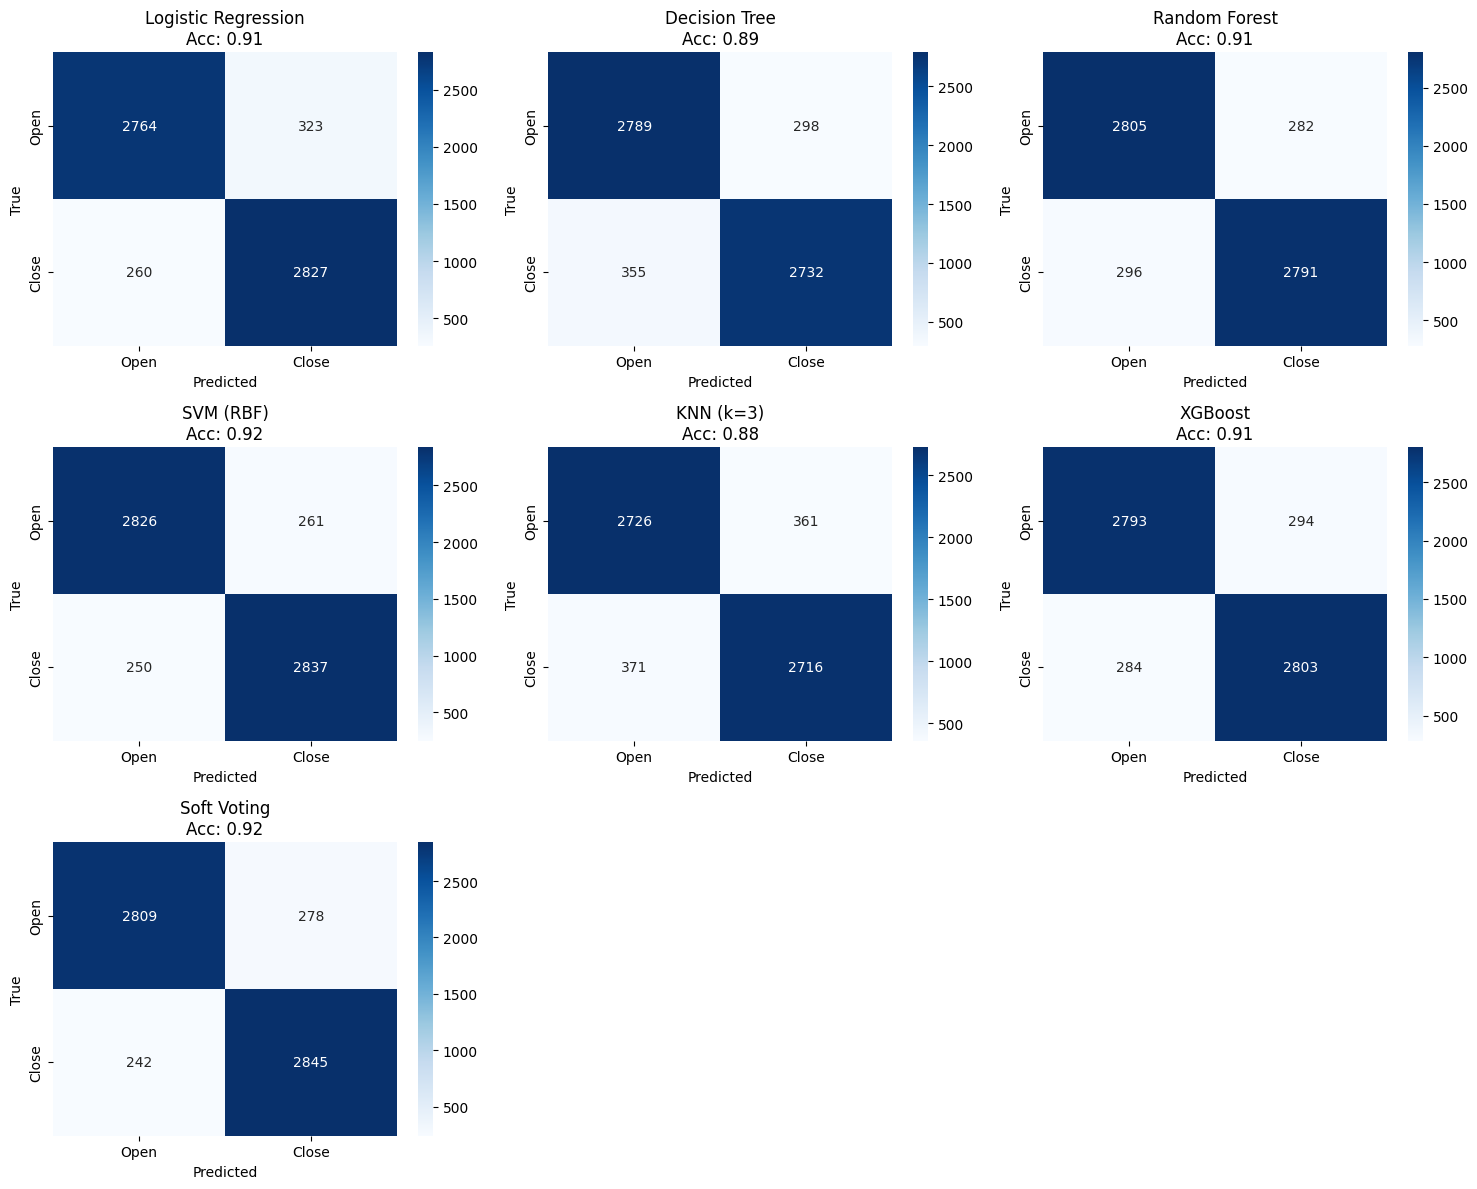

In [ ]:

model_names = list(results.keys())
num_models = len(model_names)

cols = 3
rows = math.ceil(num_models / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, name in enumerate(model_names):
    y_pred = results[name]['predictions']
    cm = confusion_matrix(Y_test, y_pred)

    plt.subplot(rows, cols, i+1)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Open', 'Close'],
        yticklabels=['Open', 'Close']
    )

    acc = results[name]['test_accuracy']
    plt.title(f"{name}\nAcc: {acc:.2f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()

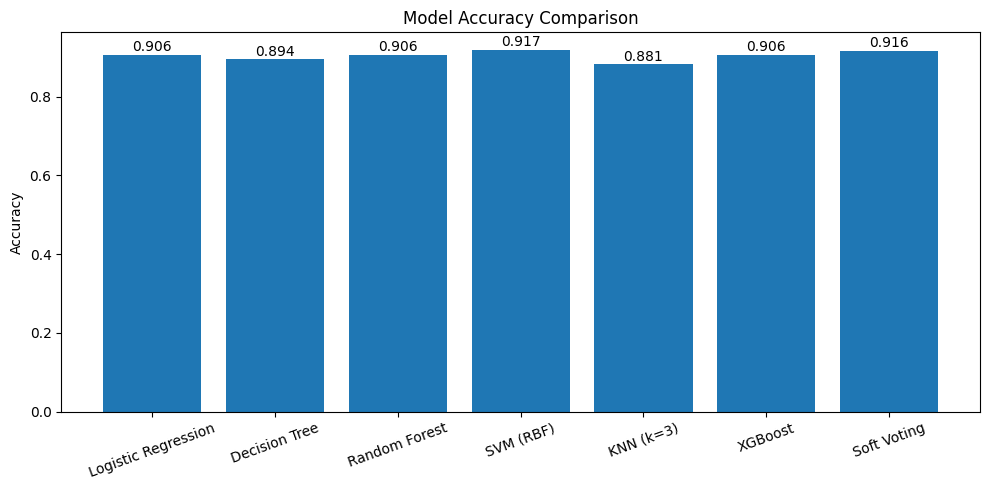

In [ ]:


# test accuracy
accuracies = [results[m]['test_accuracy'] for m in model_names]

plt.figure(figsize=(10,5))

bars = plt.bar(model_names, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.01,
        f"{acc:.3f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

### Save model (pkl)

In [ ]:
import json
import joblib

# 1) Choose best model
best_model_name = max(results.keys(), key=lambda k: results[k]['test_accuracy'])
best_model = results[best_model_name]['model']
best_accuracy = results[best_model_name]['test_accuracy']

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)
print(f"Model Name   : {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f}")

save_dir = "saved_emg_model"
os.makedirs(save_dir, exist_ok=True)

# 2) Save model
model_path = os.path.join(save_dir, "best_model.pkl")
joblib.dump(best_model, model_path)

print(f"\nModel saved to: {model_path}")


scaler_path = os.path.join(save_dir, "scaler.pkl")


try:
    joblib.dump(scaler, scaler_path)
    print(f"Scaler saved to: {scaler_path}")
    scaler_used = True
except NameError:
    print("Scaler variable not found. Skipping scaler save.")
    scaler_used = False

# 3) Save metadata

metadata = {
    "best_model_name": best_model_name,
    "test_accuracy": float(best_accuracy),
    "input_type": "feature_vector",
    "feature_extraction": [
        "MAV",
        "RMS",
        "VAR",
        "WL",
        "ZC",
        "SSC",
        "WAMP"
    ],
    "num_features_per_channel": 7,
    "class_names": ["Open", "Close"],
    "class_mapping": {
        "0": "Open",
        "1": "Close"
    },
    "scaler_used": scaler_used,
    "notes": "Input must go through the same preprocessing and feature extraction pipeline used during training."
}

metadata_path = os.path.join(save_dir, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {metadata_path}")

BEST MODEL SELECTED
Model Name   : SVM (RBF)
Test Accuracy: 0.9172

Model saved to: saved_emg_model/best_model.pkl
Scaler saved to: saved_emg_model/scaler.pkl
Metadata saved to: saved_emg_model/metadata.json
